In [1]:
import pandas as pd
import numpy as np
import requests
import json
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.python.ops.ragged.ragged_array_ops import cross_hashed
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
import pmdarima as pm
import statsmodels.api as sm
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df_full = df[(df['Date'] > '2022-08-01') & (df['Date'] < '2024-12-31')].reset_index(drop=True)
df_full[['Buy', 'Sell']] = df_full[['Buy', 'Sell']].astype(float)
df_1 = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2024-02-15')].reset_index(drop=True)
df_1[['Buy', 'Sell']] = df_1[['Buy', 'Sell']].astype(float)
df = df_full[(df_full['Date'] > '2022-08-01') & (df_full['Date'] < '2023-10-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df

,Date,Buy,Sell
0,2022-08-02,37.3365,37.7062
1,2022-08-03,37.1939,37.5547
2,2022-08-04,37.2707,37.6434
3,2022-08-05,37.2048,37.5732
4,2022-08-08,37.2963,37.6655
...,...,...,...
320,2023-10-24,38.7905,38.8044
321,2023-10-25,38.6666,38.6731
322,2023-10-26,38.4722,38.4933
323,2023-10-27,38.5290,38.5465


In [3]:
print(len(df), len(df_1), len(df_full))

325 402 630


In [4]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


In [5]:
def calculate_ols_slope(series):
    y = series.values
    x = np.arange(len(y))
    slope, intercept = np.polyfit(x, y, 1)
    return slope

def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

class AlphaBetaGammaFilter:
    def __init__(self, alpha=0.25, beta=0.005, gamma=0.001,
                 initial_value=None, initial_velocity=0, initial_accel=0,
                 adaptive=False):
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.x = initial_value
        self.v = initial_velocity
        self.a = initial_accel

        self.adaptive = adaptive
        self.estimates = []

    def my_sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def update(self, measurement, dt=1):
        if self.x is None:
            self.x = measurement
            self.estimates.append(self.x)
            return self.x

        x_pred = self.x + self.v * dt + 0.5 * self.a * (dt ** 2)
        v_pred = self.v + self.a * dt
        a_pred = self.a

        residual = measurement - x_pred

        if self.adaptive:
            min_alpha = 0.1
            max_alpha = 0.5
            center = 0.5
            slope = 2

            sigmoid_input = (abs(residual) - center) * slope
            self.alpha = min_alpha + (max_alpha - min_alpha) * self.my_sigmoid(sigmoid_input)
            self.beta = 2 * (2 - self.alpha) - 4 * np.sqrt(1 - self.alpha)
            self.gamma = (self.beta ** 2) / (2 - self.alpha)

        self.x = x_pred + self.alpha * residual
        self.v = v_pred + self.beta / dt * residual
        self.a = a_pred + (2 * self.gamma) / (dt ** 2) * residual

        self.estimates.append(self.x)
        return self.x

    def extrapolate(self, steps, dt=1):
        extrapol_results = []
        temp_x = self.x
        temp_v = self.v
        temp_a = self.a

        for i in range(steps):
            temp_x = temp_x + temp_v * dt + 0.5 * temp_a * (dt ** 2)
            temp_v = temp_v + temp_a * dt
            extrapol_results.append(temp_x)

        return np.array(extrapol_results)

def apply_kalman_smoothing(series):
    filter_1 = AlphaBetaGammaFilter(initial_value=series.iloc[0])
    smoothed_values = []

    for val in series:
        smoothed_values.append(filter_1.update(val))
    return pd.Series(smoothed_values, index=series.index)

def adf_test(series):
    result = adfuller(series.dropna())

    labels = ['ADF Statistic', 'p-value', 'lags Used', 'observations']
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val

    print(out)

    if result[1] <= 0.05:
        print('Ряд є стаціонаринм')
    else:
        print('Ряд є нестаціонарним, тому проводимо диференціювання')
        diff_result = adfuller(series.dropna().diff().dropna())
        labels = ['ADF Statistic', 'p-value', 'lags Used', 'observations']
        diff_out = pd.Series(diff_result[0:4], index=labels)

        for key, val in diff_result[4].items():
            diff_out[f'Critical Value ({key})'] = val

        print(diff_out)

        if diff_result[1] <= 0.05:
            print('Після диференціювання було визначено, що ряд є стаціонарним')
        else:
            print('Після диференціювання було остаточно визначено, що ряд є не стаціонарним')

def decomposition(df_to_dec, col_to_dec, time_range_to_dec_start, time_range_to_dec_stop, period=5):
    # Decomposition
    df_decomposed = df_to_dec.set_index('Date')
    decomposition = seasonal_decompose(x=df_decomposed[col_to_dec], period=period, model='additive')
    df_decomposed = pd.concat([df_decomposed, decomposition.trend, decomposition.seasonal, decomposition.resid], axis=1)

    residuals = decomposition.resid.dropna()
    observed_values = decomposition.observed.loc[residuals.index]
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((observed_values - observed_values.mean()) **2 )

    if ss_tot == 0:
        R2_decompose = 1.0
    else:
        R2_decompose = 1 - (ss_res / ss_tot)

    print(f"Показник R^2 для моделі декомпозиції: {R2_decompose:.4f}")

    # Setting some additional parameters for the next plots
    fig, ax = plt.subplots(2, 2, layout='constrained', width_ratios=[0.6, 0.4])
    fig.set_figheight(6)
    fig.set_figwidth(10)
    ax[0][0].tick_params(axis='x', labelrotation=45)
    ax[0][0].set_xlabel('Графік показника сезонності протягом 2024 року')
    ax[0][1].set_xticks(ticks=df_to_dec[::period]['Date'], labels=df_to_dec[::period]['Date'].astype(str), rotation=45, size=8)
    date_parts = time_range_to_dec_start.split('/')
    ax[0][1].set_xlabel('Графік показника сезонності протягом {0} місяця {1} року'.format(date_parts[1], date_parts[0]))
    ax[1][0].tick_params(axis='x', labelrotation=45)
    ax[1][0].set_xlabel('Графік чистого тренду без включення елементів сезонності та \n"шуму"(залишкової компоненти)')
    ax[1][1].tick_params(axis='x', labelrotation=45)
    ax[1][1].set_xlabel('Графік залишкової компоненти(шуму)')
    # fig.tight_layout()

    ax[0][0].plot(df_decomposed['seasonal'], color='g')
    try:
        ax[0][1].plot(df_decomposed['seasonal'][time_range_to_dec_start:time_range_to_dec_stop], color='g')
    except Exception as e:
        print(f"Помилка при побудові зрізу: {e}")
    ax[1][0].plot(df_decomposed['trend'], color='b')
    ax[1][1].plot(df_decomposed['resid'], color='b')
    # '2024/02/01'

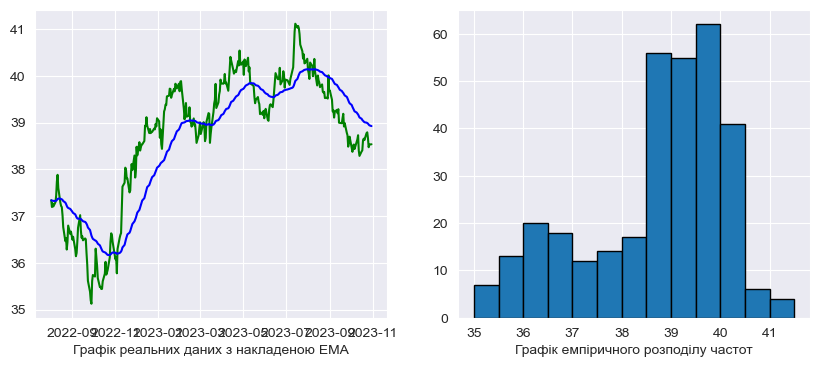

In [6]:
draw_plots(df, 'Date', 'Buy')

Показник R^2 для моделі декомпозиції: 0.9921


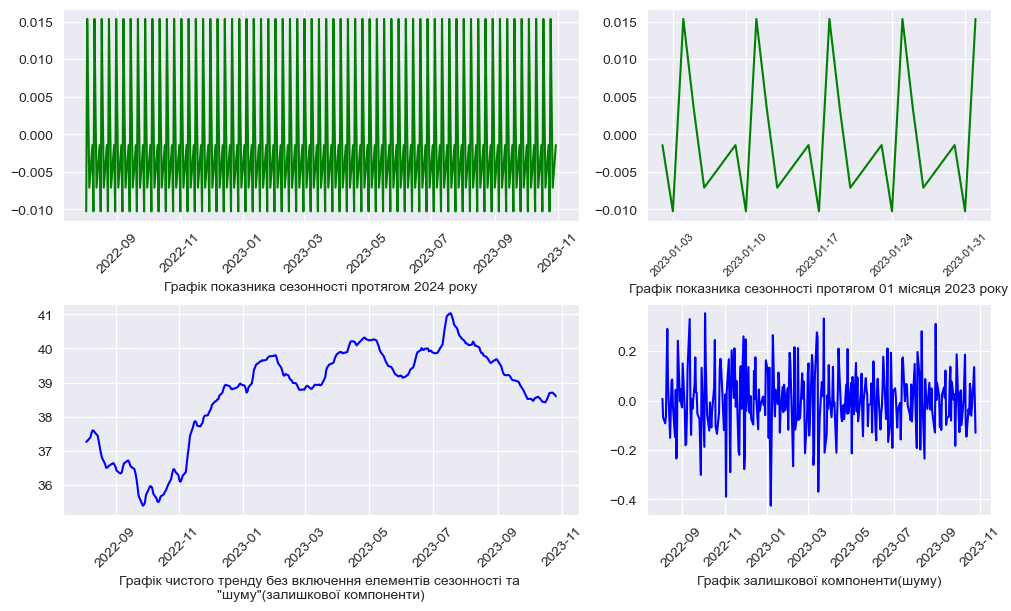

In [7]:
decomposition(df, 'Buy', '2023/01/01', '2023/02/01')

In [8]:
df['Log_Diff'] = np.log(df['Buy']).diff().dropna()
df['Log_Buy'] = np.log(df['Buy']).dropna()
df_1['Log_Diff'] = np.log(df_1['Buy']).diff().dropna()
df_1['Log_Buy'] = np.log(df_1['Buy']).dropna()
df_full['Log_Diff'] = np.log(df_full['Buy']).diff().dropna()
df_full['Log_Buy'] = np.log(df_full['Buy']).dropna()

print('Тест Діккі-Фуллера для тренувального датасету: ')
adf_test(df['Buy'])

print('\nТест Діккі-Фуллера для повного датасету')
adf_test(df_full['Buy'])

print('\nТест Діккі-Фуллера для тренувального датасету після логарифмування')
adf_test(df['Log_Diff'])

Тест Діккі-Фуллера для тренувального датасету: 
ADF Statistic            -1.437593
p-value                   0.564127
lags Used                 0.000000
observations            324.000000
Critical Value (1%)      -3.450695
Critical Value (5%)      -2.870502
Critical Value (10%)     -2.571545
dtype: float64
Ряд є нестаціонарним, тому проводимо диференціювання
ADF Statistic          -1.779154e+01
p-value                 3.245718e-30
lags Used               0.000000e+00
observations            3.230000e+02
Critical Value (1%)    -3.450759e+00
Critical Value (5%)    -2.870530e+00
Critical Value (10%)   -2.571560e+00
dtype: float64
Після диференціювання було визначено, що ряд є стаціонарним

Тест Діккі-Фуллера для повного датасету
ADF Statistic            -1.026101
p-value                   0.743626
lags Used                 0.000000
observations            629.000000
Critical Value (1%)      -3.440789
Critical Value (5%)      -2.866146
Critical Value (10%)     -2.569223
dtype: float64
Ряд 

In [99]:
def plot_correlograms(series):
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(series.dropna(), lags=40, ax=ax[0])
    ax[0].set_title('Autocorrelation (ACF)')

    plot_pacf(series.dropna(), lags=40, ax=ax[1], method='ywm')
    ax[1].set_title('Partial Autocorrelation (PACF)')

    plt.tight_layout()
    plt.show()

def find_best_arima(series):
    model = pm.auto_arima(series,
                          start_p=0, start_q=0,
                          max_p=5, max_q=5,
                          d=1,
                          seasonal=False,
                          start_P=0, D=0,
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

    print(f"\nНайкраща модель: {model.order}")
    return model

def find_seasonal_arima(series):
    model = pm.auto_arima(series,
                          start_p=1, start_q=1,
                          max_p=3, max_q=3,
                          d=1,

                          seasonal=True,
                          m=5,
                          start_P=0, start_Q=0,
                          max_P=2, max_Q=2,
                          D=None,

                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

    print(f"\nНайкраща модель: {model.order} x {model.seasonal_order}")
    return model

def arima_walk_forward(train_data, test_data, order):
    history = [x for x in train_data]
    predictions = []

    for t in range(len(test_data)):
        model = ARIMA(history, order=order)
        model_fit = model.fit()

        yhat = model_fit.forecast()[0]
        predictions.append(yhat)

        obs = test_data.iloc[t]
        history.append(obs)

    return np.array(predictions)

def evaluate_extrapolation(true_values, pred_values, title="ARIMA Results"):
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(true_values, pred_values) * 100

    print(f"--- {title} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")

    plt.figure(figsize=(14, 7))
    plt.plot(true_values.index, true_values, label='Реальна ціна', color='green')
    plt.plot(true_values.index, pred_values, label='ARIMA Прогноз', color='red', linestyle='--')

    plt.title(f'{title} (MAPE: {mape:.2f}%)')
    plt.xlabel('Дата')
    plt.ylabel('Курс EUR/UAH')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def main_filter_process(filter, custom_norm_df, col_name, steps_num=5):
    # Going through the data
    filtered_data = []
    for price in custom_norm_df[col_name].values:
        filtered_data.append(filter.update(price))

    # Extrapolation process
    extrapol_results = filter.extrapolate(steps=steps_num)
    return np.concatenate((np.array(filtered_data), extrapol_results), axis=None)

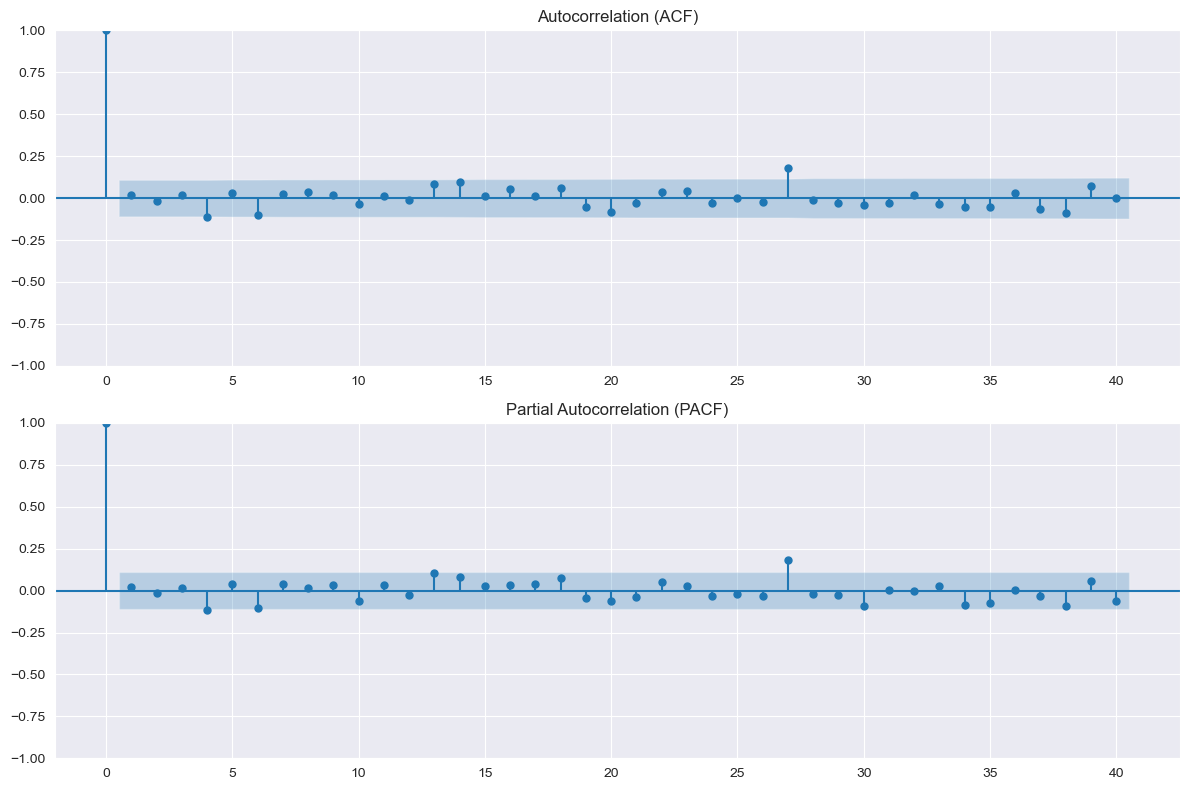

In [10]:
plot_correlograms(df['Log_Diff'])

In [72]:
def use_all_ARIMA(df_to_call, col, test_procent=20):
    n_test = int(len(df_to_call) * (test_procent / 100))
    n_train = int(len(df_to_call) * ((100 - test_procent) / 100))

    best_model = find_best_arima(df_to_call[col])
    # seasonal_model = find_seasonal_arima(df['Log_Buy'])'

    log_predictions = arima_walk_forward(df_to_call[:n_train][col], df_to_call[n_train+1:][col], best_model.order)
    predictions_uah = np.exp(log_predictions)
    real_values_uah = np.exp(df_to_call[col].iloc[n_train+1:])
    evaluate_extrapolation(real_values_uah, predictions_uah)

    return best_model

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-3080.321, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-3079.036, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-3079.069, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-3081.614, Time=0.03 sec


/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-3079.512, Time=0.24 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.603 seconds

Найкраща модель: (0, 1, 0)
Here
 ARIMA(0,1,0)(0,0,0)[0]          


/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retva

--- ARIMA Results ---
RMSE: 0.2039
MAPE: 0.3847%


/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


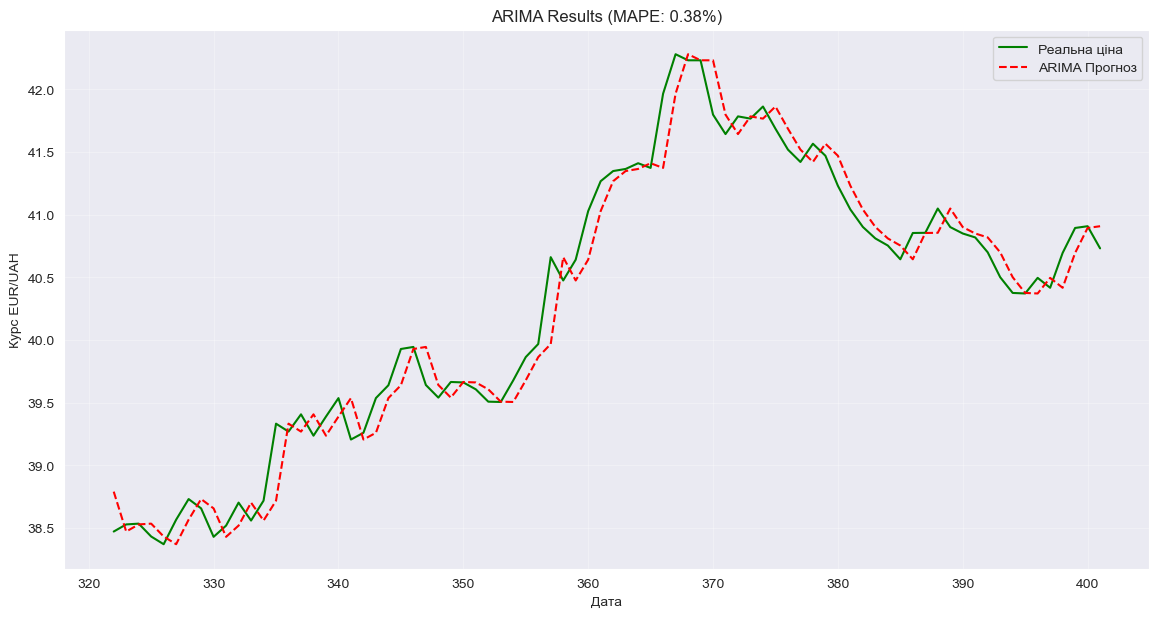

 ARIMA(0,1,0)(0,0,0)[0]          


In [46]:
arima_model = use_all_ARIMA(df_1, 'Log_Buy')
print(arima_model)

In [123]:
def arima_extrapolate(df_to_call, full_dataset, col, n_days=10):
    series_log = np.log(df_to_call[col])
    model = pm.auto_arima(series_log,
                          start_p=0, start_q=0,
                          max_p=5, max_q=5,
                          d=1,
                          seasonal=False,
                          trace=False,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

    fc, conf_int = model.predict(n_periods=n_days, return_conf_int=True)

    fc_uah = np.exp(fc)
    conf_int_uah = np.exp(conf_int)

    last_date = df_to_call['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date, periods=n_days + 1, freq='B',)[1:]

    forecast_df = pd.DataFrame({
        'Date': future_dates,
        'Forecast': fc_uah,
        'Lower_Bound': conf_int_uah[:, 0],
        'Upper_Bound': conf_int_uah[:, 1]
    })

    start_idx = len(df_to_call)
    end_idx = start_idx + n_days

    if end_idx <= len(full_dataset):
        true_values = full_dataset[col].iloc[start_idx:end_idx].values

        mse = mean_squared_error(true_values, fc_uah)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(true_values, fc_uah) * 100

        metrics_title = f"RMSE: {rmse:.4f}, MAPE: {mape:.2f}%"
    else:
        metrics_title = "Немає майбутніх даних для оцінки"
    print(f"ARIMA Evaluation\n{metrics_title}")

    plt.figure(figsize=(12, 6))
    plt.plot(full_dataset['Date'], full_dataset[col], label='Повна історія', color='blue')
    plt.plot(df_to_call['Date'], df_to_call[col], label='Частковий датасет')
    plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='ARIMA Прогноз', color='red', linestyle='--')

    plt.fill_between(forecast_df['Date'],
                     forecast_df['Lower_Bound'],
                     forecast_df['Upper_Bound'],
                     color='pink', alpha=0.3, label='95% Довірчий інтервал')

    plt.title(f'Екстраполяція курсу EUR/UAH на {n_days} днів вперед')
    plt.xlabel('Дата')
    plt.ylabel('Курс')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(forecast_df.head())

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/var-roman/anaconda3/envs/Analysis_and_

ARIMA Evaluation
RMSE: 3.3754, MAPE: 6.95%


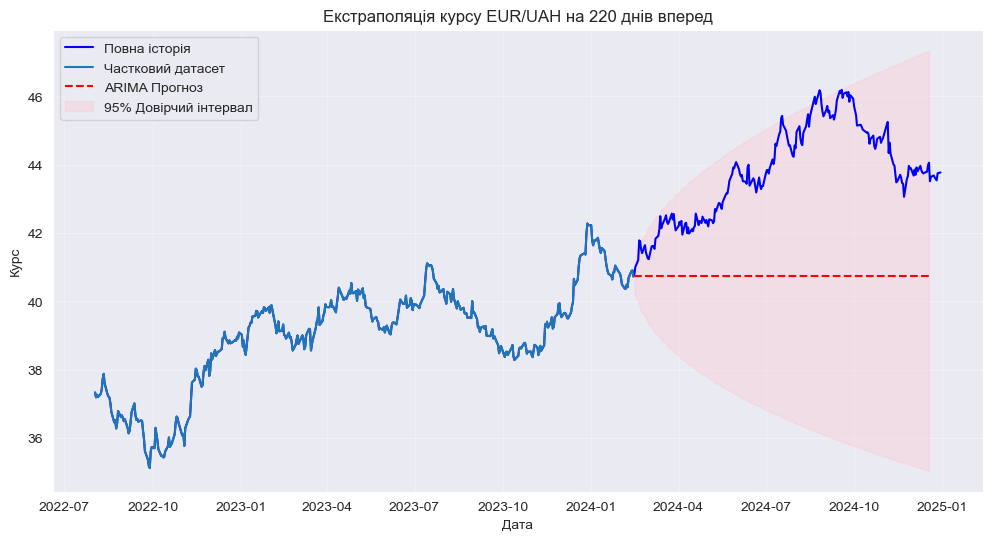

          Date  Forecast  Lower_Bound  Upper_Bound
402 2024-02-15   40.7315    40.320763    41.146421
403 2024-02-16   40.7315    40.151846    41.319522
404 2024-02-19   40.7315    40.022712    41.452841
405 2024-02-20   40.7315    39.914169    41.565567
406 2024-02-21   40.7315    39.818785    41.665136


In [124]:
arima_extrapolate(df_1, df_full, 'Buy', 220)

Kalman Filter Evaluation
RMSE: 1.3092, MAPE: 2.38%


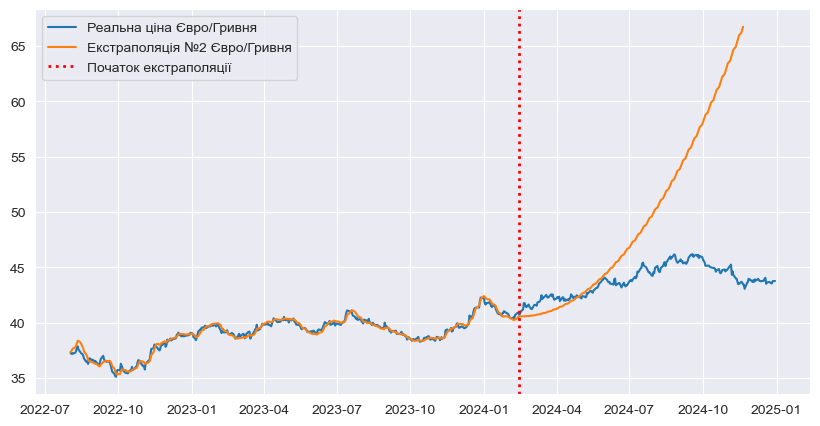

In [125]:
scaler = StandardScaler()
scaler.fit(df[['Buy']])

norm_df_1 = df_1.copy().drop('Sell', axis=1)
norm_df_1[['Buy']] = scaler.transform(df_1[['Buy']])
filter_2 = AlphaBetaGammaFilter(alpha=0.4, beta=0.1, gamma=0.003,
                 initial_value=None, initial_velocity=0.1, initial_accel=0.05,
                 adaptive=True)

concatenated_result_1 = main_filter_process(filter_2, norm_df_1, 'Buy', 200)
real_price_extrapolation_1 = scaler.inverse_transform(concatenated_result_1.reshape(-1, 1))

start_idx = len(df_1)
end_idx = start_idx + n_days_predict

if end_idx <= len(df_full):
    real_data_future = df_full['Buy'].iloc[start_idx:end_idx].values

    rmse_kalman = np.sqrt(mean_squared_error(real_data_future, kalman_forecast))
    mape_kalman = mean_absolute_percentage_error(real_data_future, kalman_forecast) * 100

    metrics_text = f"RMSE: {rmse_kalman:.4f}, MAPE: {mape_kalman:.2f}%"
else:
    metrics_text = "N/A (Not enough data)"
print(f"Kalman Filter Evaluation\n{metrics_text}")

fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(df_full['Date'], df_full['Buy'], label='Реальна ціна Євро/Гривня')
plt.plot(df_full['Date'][:len(real_price_extrapolation_1)], real_price_extrapolation_1, label='Екстраполяція №2 Євро/Гривня')
plt.axvline(x=norm_df_1['Date'].iloc[-1], color='red', linestyle=':', linewidth=2, label='Початок екстраполяції')
plt.legend()
plt.plot();